A script for making spatial firing plots for chosen cells
- compare firing in explore and homing
- show a few cells making a pattern in homing and being all over in explore
- show the firing in homing and explore colored by hdir

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may", "JAL8_flip4_10may"] 

In [ ]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from behave_analysis.visualize.efizz.heatmap import assign_positional_bins_to_frames
from behave_analysis.utils.heatplot_utils import filter_outside_arena_tracking_for_video_and_spike_data
from JR_test_scripts.escape.functions.escape_utils import load_homing
from JR_test_scripts.escape.functions.escape_data_loading_funcs import extract_homing_and_escape_periods
import matplotlib.gridspec as gridspec
from behave_analysis.visualize.behaviour.behavioral_stats import hsv_hdir_colormap
from JR_test_scripts.FigureSaver import Figure_Saver

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from loguru import logger
import dill as pickle
from pathlib import Path
import matplotlib.patches as patches
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF
from matplotlib.colors import hsv_to_rgb
from scipy.ndimage import gaussian_filter1d
import matplotlib.colors as mcolors
import seaborn as sns

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
"""Load the data"""
e = 7
exp = experiments_objects[e]
session_name = session_names[e]
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Cosyne/")
tuning_data = '_25bins' # '' or '_50bins' or '_25bins
cond_colors = ['#228B22','#FF8C00','#008B8B']
homing_color = '#6A0DAD'
escape_color = '#E63946'
dot_size = 2
panel_size = 5

In [ ]:
"""Load data"""
# load session
session = Process(exp).load_session()

# load hdir cells
dir = Path("Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\head_direction_cells.pkl")
with open(dir, "rb") as dill_file:
    hdir = pickle.load(dill_file)

# load video & spike data
COLUMNS_TO_KEEP = [
    "mouse_x_position",
    "mouse_y_position",
    "spike_clusters",
    "spike_count",
    "OutofshelterIdx",
    "EscapePeriod",
    "shelter",
    "barrier_present",
    "barrier_flipped",
    "hdir",
    "homingPeriod", # 'homingPeriod'
]
base_path = os.path.join(session['base_path'], session['processed_path'])
video_and_spike_data = pl.read_parquet(
                os.path.join(base_path + "\\" + "good_video_spike_count_df.parquet"), 
                low_memory=True,
                use_pyarrow = True,
                memory_map=True,
            )
# NOTE: be careful!! use spike_count in this df to actually get the firing rate, 
# assuming that each entry is worth one spike is WRONG

# load homings
h_on, h_off, homing_bool = load_homing(session, int(np.amax(np.unique(video_and_spike_data['frames'].to_numpy()))))
if "homingPeriod" not in video_and_spike_data.columns:    
    video_and_spike_data = video_and_spike_data.with_columns(
        pl.col('frames').cast(pl.Int64).alias('frames')
    )
    homing_frames = [homing_bool[frame-1] for frame in video_and_spike_data['frames'].to_list()]
    video_and_spike_data = video_and_spike_data.hstack([pl.Series("homingPeriod", homing_frames)])

# post process video and spike data
video_and_spike_data = video_and_spike_data.select(COLUMNS_TO_KEEP)
clean_video_df = filter_outside_arena_tracking_for_video_and_spike_data(video_and_spike_data=video_and_spike_data, session=session).to_pandas()
df = pl.DataFrame(clean_video_df)

# select units of interest
unit_ids = video_and_spike_data["spike_clusters"].unique().to_numpy()
if unit_ids[0] == 0: unit_ids = unit_ids[1:]
unit_ids = unit_ids

# full x and y pos
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))
y_pos = video_df["mouse_y_position"].to_numpy()
x_pos = video_df["mouse_x_position"].to_numpy()
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()
video_df = video_df.hstack([pl.Series("homingPeriod", homing_bool)])

# booleans for homing+escape and explore
h_e_bool = (homing_bool | video_df['EscapePeriod'].to_numpy()) & (video_df['OutofshelterIdx'].to_numpy())
exp_bool = ((homing_bool == False) & (video_df['EscapePeriod'].to_numpy() == False)) & (video_df['OutofshelterIdx'].to_numpy())
cond = np.zeros(len(bar))
cond[bar] += 1
cond[barflip] += 1

X = x_pos[h_e_bool]
Y = y_pos[h_e_bool]
h_cond = cond[h_e_bool]

X_exp = x_pos[exp_bool]
Y_exp = y_pos[exp_bool]
exp_cond = cond[exp_bool]

2025-03-20 08:50:10.316 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [5]:
def filter_video_dataframe(dataframe, condition, outofshelter=True, behavior = 'homing'):
    """
    A function that filters the video dataframe (the behavioural data) and finds the periods of time in each condition (defined by object presence (whether the barrier or shelter is present or not))
    Time in shelter is removed
    optionally times when the mouse is escaping (x seconds after threat) are also removed
    """
    filtered_video_df = dataframe.filter((dataframe["OutofshelterIdx"] == outofshelter))

    if behavior == 'homing':
        filtered_video_df = filtered_video_df.filter((filtered_video_df["homingPeriod"] == True) | (filtered_video_df["EscapePeriod"] == True))
    elif behavior == 'exploring':
        filtered_video_df = filtered_video_df.filter((filtered_video_df["homingPeriod"] == False) & (filtered_video_df["EscapePeriod"] == False))

    if condition == "shelter_only":  # only the shelter is present (before the barrier!!)
        filtered_video_df = filtered_video_df.filter((filtered_video_df["shelter"] == True))
        if "barrier_present" in filtered_video_df.columns:
            barrier = filtered_video_df["barrier_present"].to_numpy()  # present regardless of removal
            barrier_present = np.arange(1, len(barrier) + 1) < np.where(np.diff(barrier.astype(int)) == 1)[0]
            filtered_video_df = filtered_video_df.filter((barrier_present))

    elif condition == "barrier_present":  # the hwole time the barrier is present
        filtered_video_df = filtered_video_df.filter((filtered_video_df["barrier_present"] == True))

    elif condition == "barrier_pre_flip":  # the barrier is present, before we flip it
        filtered_video_df = filtered_video_df.filter((filtered_video_df["barrier_present"] == True) & (filtered_video_df["barrier_flipped"] == False))

    elif condition == "barrier_post_flip":  # the barrier is present, after we flip it
        filtered_video_df = filtered_video_df.filter((filtered_video_df["barrier_present"] == True) & (filtered_video_df["barrier_flipped"] == True))

    return filtered_video_df

In [227]:
def add_arena(axs, condition, scale = 1):
    # Add center circle
    circle = plt.Circle((512*scale, 512*scale), 460*scale, color='k', fill=False, linewidth=2)
    axs.add_patch(circle)

    # Add red transparent square
    square = patches.Rectangle((437*scale, 886*scale), 150*scale, 90*scale, facecolor='r', alpha=0.4, edgecolor=None, linewidth=0)
    axs.add_patch(square)

    if condition == 'barrier':
        axs.plot([(512-280)*scale,(512+460)*scale], [512*scale,512*scale], 'k', linewidth=2)
    elif condition == 'flipped_barrier':
        axs.plot([(512-460)*scale,(512+280)*scale], [512*scale,512*scale], 'k', linewidth=2)

RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_SpatialFiring_Neuron229_Cluster513_barrier.png already exists.


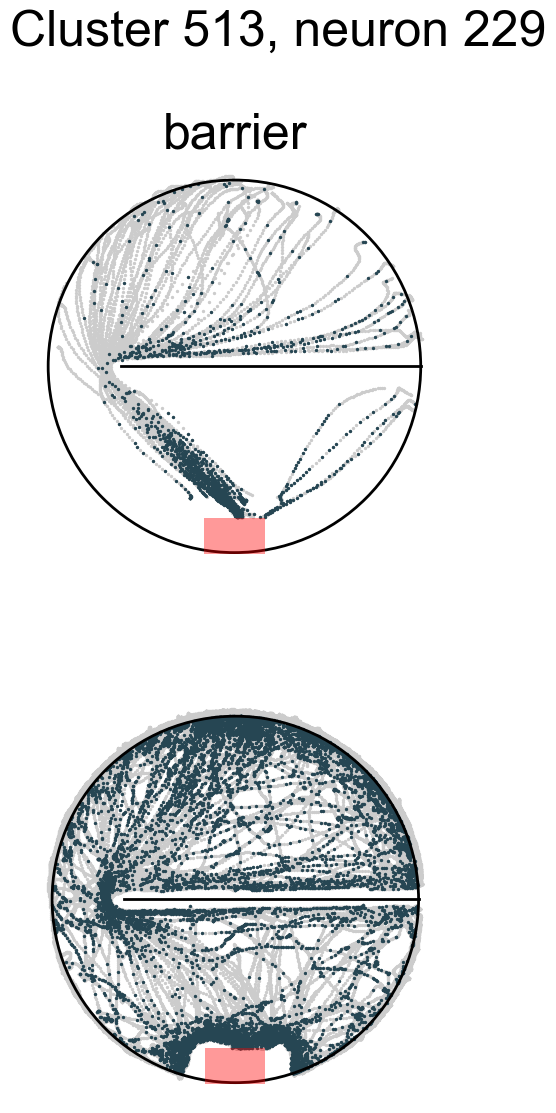

In [141]:
"""Where did the neuron fire in space?
scatter the spikes onto the homing/escape or exploration behavior"""
selected = [119, 126,229]
# selected = [17, 226, 229]
colors = ["#E63946", "#2A9D8F", "#264653"]

selected = selected[2] # the index of good neuron
clu = unit_ids[selected] # the KS cluster name
color = colors[2] # 'C0'

fig = plt.figure(figsize=(panel_size*3, 2+(panel_size*2)))
gs = gridspec.GridSpec(2, 4, width_ratios=[5, 5, 5, .5])
spikes = df.filter((df['spike_clusters'] == clu))

for idx, condition in enumerate(['barrier_pre_flip']):
    idx = 1 # conditions
    # make the plot for homings
    ax = fig.add_subplot(gs[0, idx])

    # plot the homing trajectories
    ax.scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = dot_size)
    
    # plot the spikes
    filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'homing')
    ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
                filtered_df['mouse_y_position'].to_numpy(), s = dot_size, c = color)
    add_arena(ax, c_names[idx])
    ax.set_axis_off()
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(c_names[idx])

    # make the plot for explore
    ax = fig.add_subplot(gs[1, idx])

    # plot the homing trajectories
    ax.scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = dot_size)
    
    # plot the spikes
    filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'exploring')
    ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
                filtered_df['mouse_y_position'].to_numpy(), s = dot_size, c = color)
    add_arena(ax, c_names[idx])
    ax.set_axis_off()
    ax.invert_yaxis()
    ax.set_aspect('equal')


fig.suptitle(f'Cluster {clu}, neuron {selected}')
plt.tight_layout()

figure_saver = Figure_Saver(dir_save=save_path, format_save=["png"], overwrite = True)
figure_saver.save(fig, name_file=session_name + '_SpatialFiring_Neuron' + str(selected) + '_Cluster' + str(clu) + '_' + c_names[idx])


In [ ]:
from scipy.stats import gaussian_kde

def compute_spatial_density(x_pos, y_pos, bandwidth=30):
    """
    Compute spatial density of spikes using KDE.
    Higher values indicate more nearby spikes.
    
    Parameters:
    -----------
    x_pos, y_pos : arrays
        The x and y positions of the spikes
    bandwidth : float
        Controls smoothing (higher = more smoothing)
        
    Returns:
    --------
    density : array
        Density value for each spike point
    """
    # Check if we have enough points
    if len(x_pos) < 5:
        return np.ones_like(x_pos)  # Return uniform density if too few points
    
    # Combine positions into a single array
    positions = np.vstack([x_pos, y_pos])
    
    # Create KDE
    kde = gaussian_kde(positions, bw_method=bandwidth/1024)
    
    # Evaluate KDE at each point
    density = kde(positions)
    
    return density

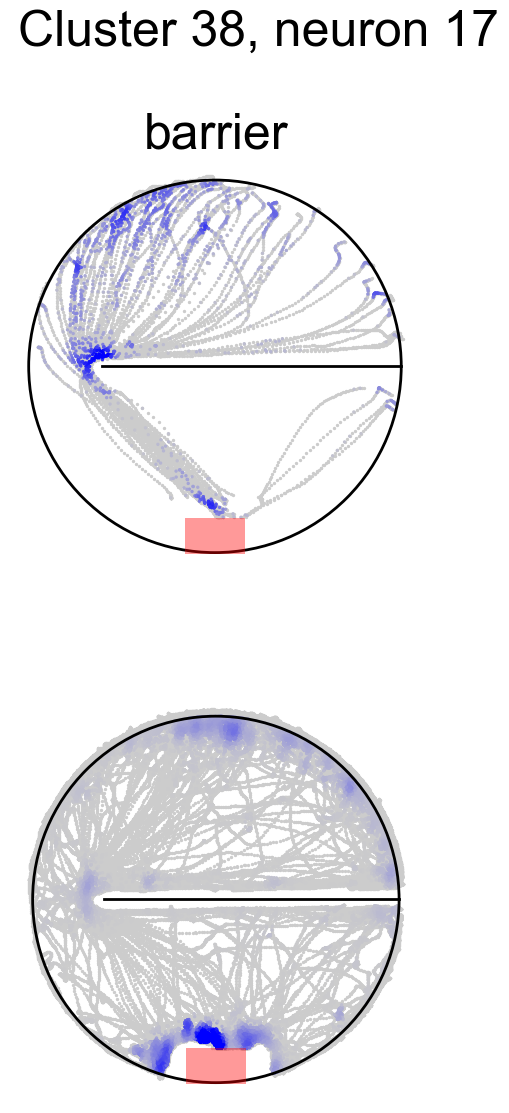

In [ ]:
"""Where did the neuron fire in space?
scatter the spikes onto the homing/escape or exploration behavior"""

# Create a custom colormap that transitions from grey to red
colors = [(0.8, 0.8, 0.8), (0.0, 0.0, 1.0)]  # Grey to red
grey_to_red = mcolors.LinearSegmentedColormap.from_list('grey_to_red', colors)

selected = 17 # the index of good neuron
clu = unit_ids[selected] # the KS cluster name

bandwidth = 50

fig = plt.figure(figsize=(panel_size*3, 2+(panel_size*2)))
gs = gridspec.GridSpec(2, 4, width_ratios=[5, 5, 5, .5])
spikes = df.filter((df['spike_clusters'] == clu))

for idx, condition in enumerate(conditions):

    for he, behavior in enumerate(['homing', 'exploring']):
        # make the plot for homings
        ax = fig.add_subplot(gs[he, idx])
        if he == 0:
            # plot the homing trajectories
            ax.scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = dot_size)
            ax.set_title(c_names[idx])
        elif he == 1:
            # plot the exploration behavior
            ax.scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = dot_size)

        # plot the spikes
        filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = behavior)
        density = compute_spatial_density(filtered_df['mouse_x_position'].to_numpy(),
                                        filtered_df['mouse_y_position'].to_numpy(), bandwidth=bandwidth)
        ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
                    filtered_df['mouse_y_position'].to_numpy(), s = 2, 
                    c = density, cmap = grey_to_red,
                    norm=plt.Normalize(vmin=0, vmax=np.max(density)*0.8))
        add_arena(ax, c_names[idx])
        ax.set_axis_off()
        ax.invert_yaxis()
        ax.set_aspect('equal')

fig.suptitle(f'Cluster {clu}, neuron {selected}')
plt.tight_layout()

# figure_saver = Figure_Saver(dir_save=save_path, format_save=["png"], overwrite = True)
# figure_saver.save(fig, name_file=session_name + '_SmoothSpatialFiring_Neuron' + str(selected) + '_Cluster' + str(clu) + '_' + c_names[idx])

RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_SmoothSpatialFiring_Neuron229.png already exists.


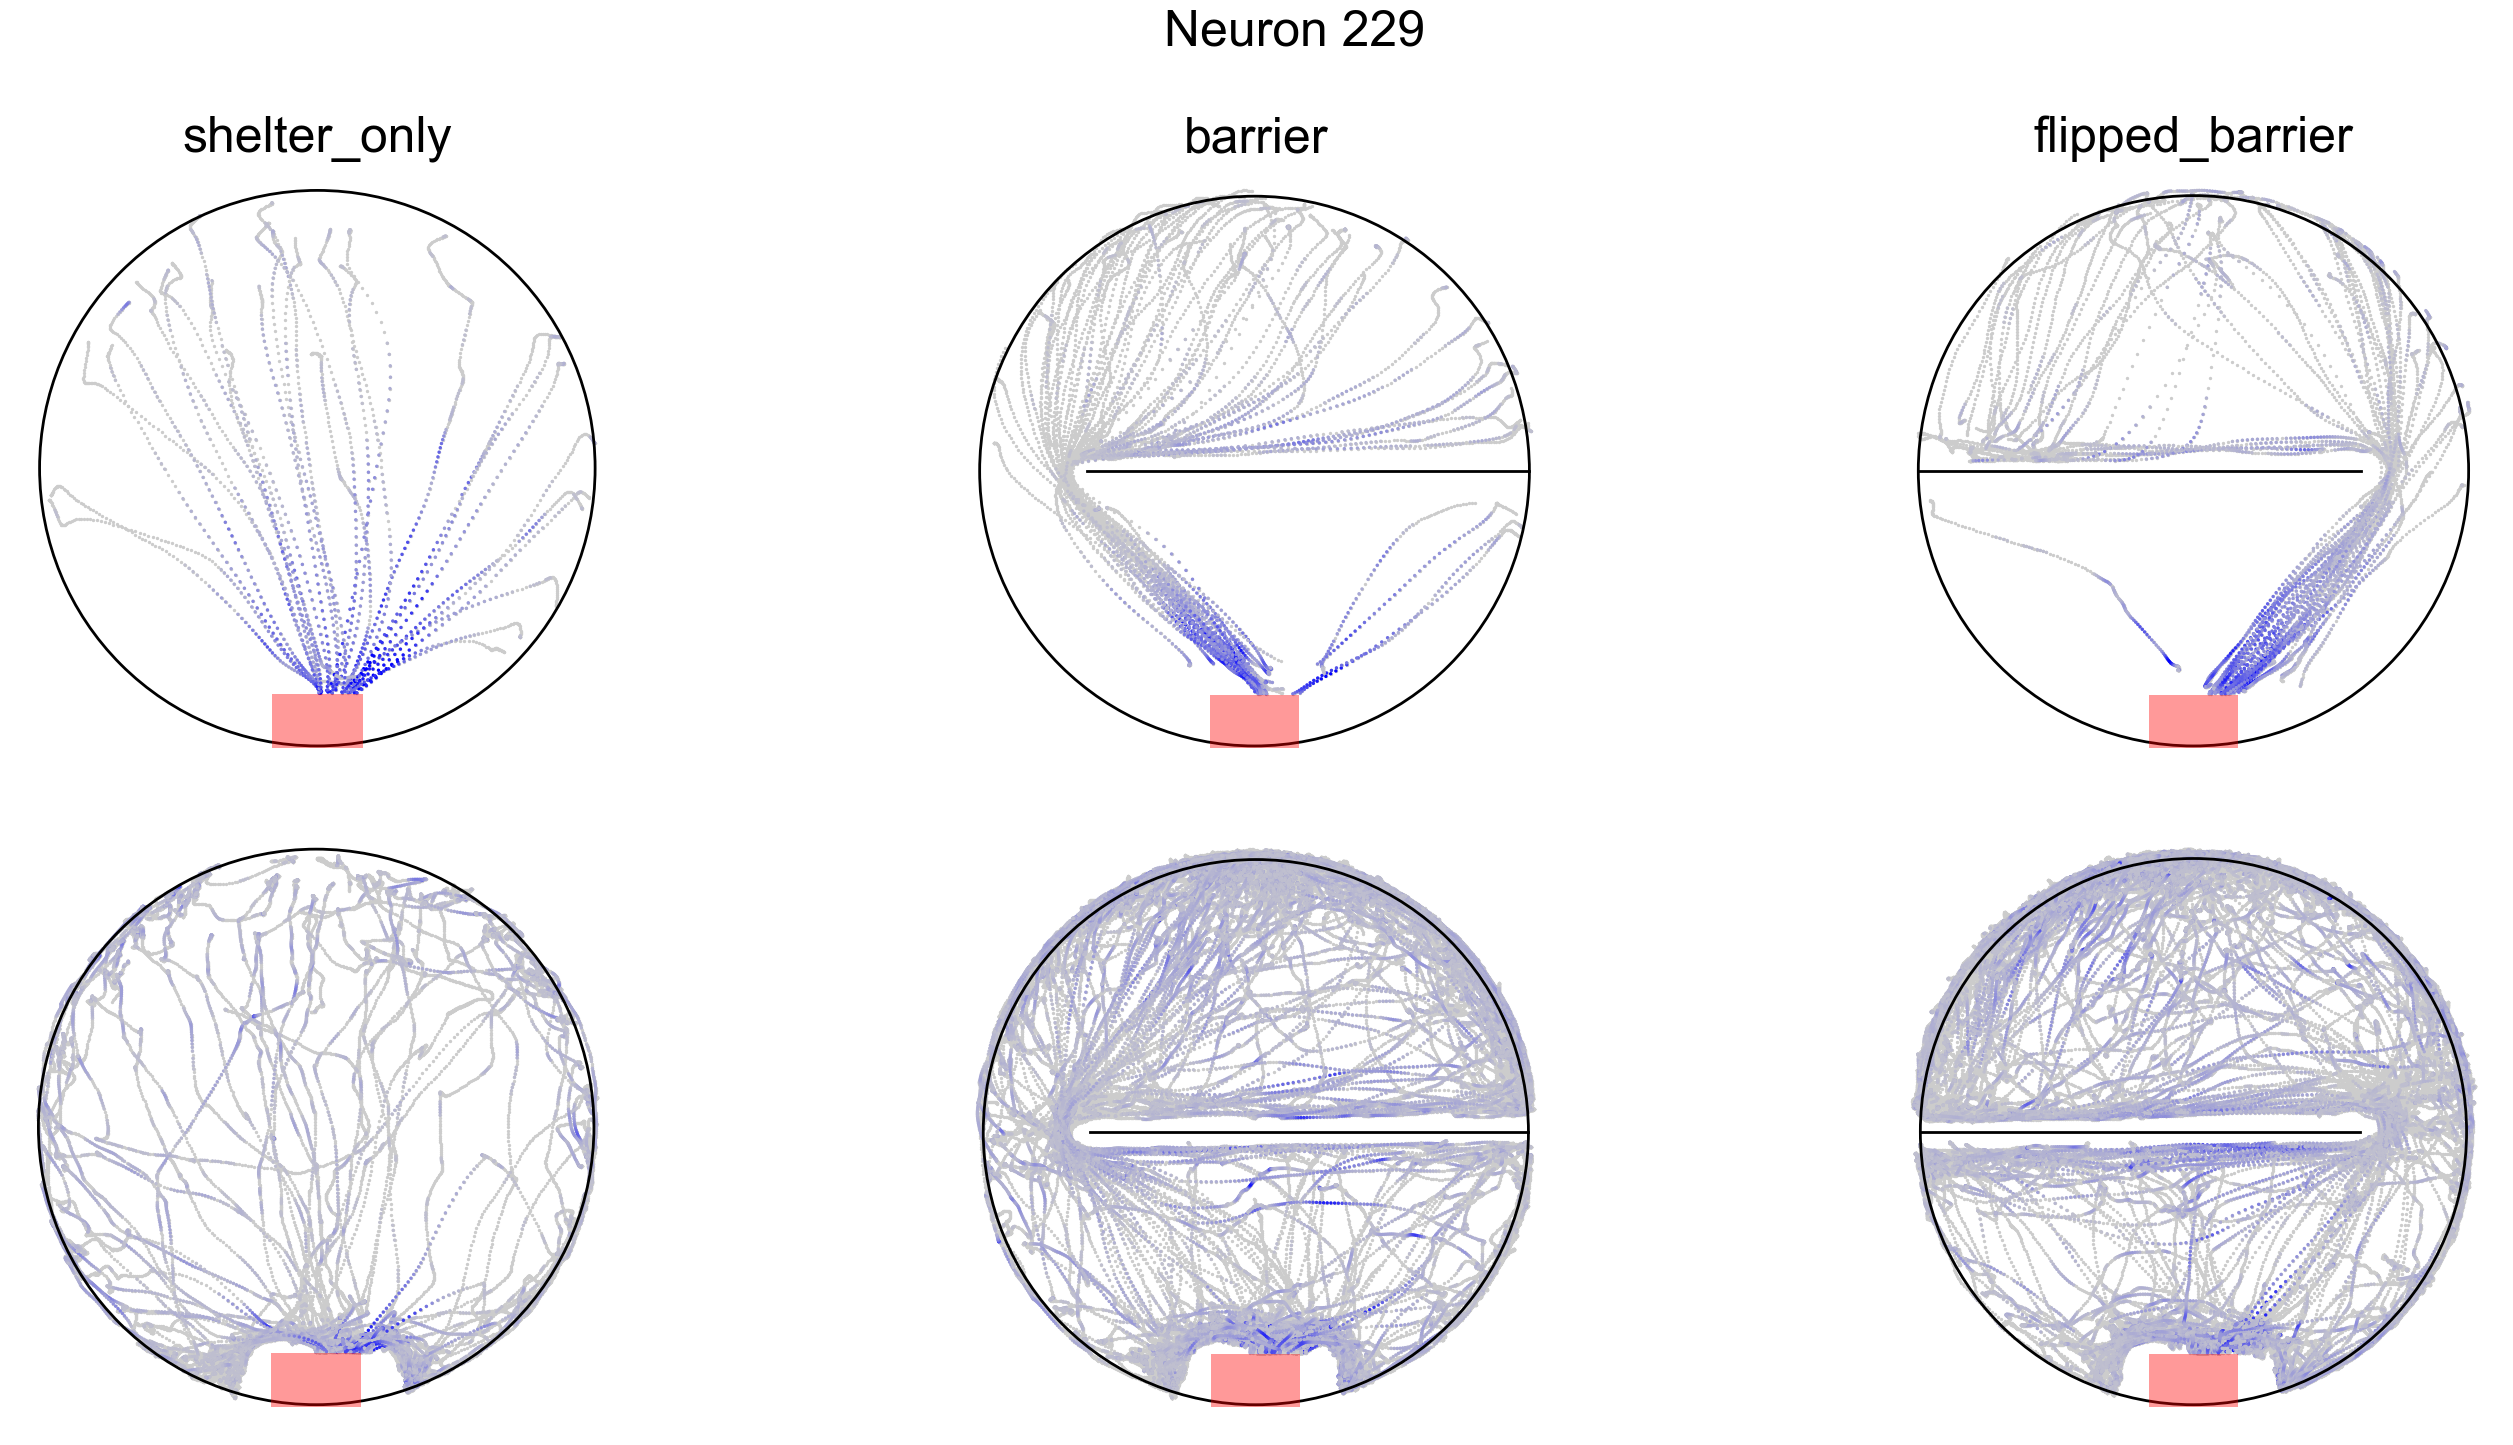

In [ ]:
"""Where did the neuron fire in space?
show activity onto the homing/escape or exploration behavior,
but this time show firing rate instead of individual spikes"""

# matrix
frame_by_cluster_matrix = np.load(
    os.path.join(session['base_path'], session['processed_path'])
    + "\\"
    + "frame_by_good_cluster_matrix.npy"
)

# Create a custom colormap that transitions from grey to red
colors = [(0.8, 0.8, 0.8), (0.0, 0.0, 1.0)]  # Grey to red
grey_to_red = mcolors.LinearSegmentedColormap.from_list('grey_to_red', colors)

selected = 229 # the index of good neuron

fig = plt.figure(figsize=(panel_size*3, 2+(panel_size*2)))
gs = gridspec.GridSpec(2, 4, width_ratios=[5, 5, 5, .5])
spikes = gaussian_filter1d(frame_by_cluster_matrix[:, selected], 2)
spikes[frame_by_cluster_matrix[:, selected] == 0] = 0
homing_activity = spikes[h_e_bool]
explore_activity = spikes[exp_bool]

# For the colormap
vmin = min(np.min(homing_activity), np.min(explore_activity))
vmax = max(np.max(homing_activity), np.max(explore_activity))*.8

for idx, condition in enumerate(conditions):
    # make the plot for homings
    ax = fig.add_subplot(gs[0, idx])

    ax.scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = dot_size)
    
    # plot the spikes
    in_cond_non_zero = (h_cond == idx) & (homing_activity > 1)
    ax.scatter(X[in_cond_non_zero], Y[in_cond_non_zero], 
               s = dot_size, c = homing_activity[in_cond_non_zero], 
               cmap = grey_to_red, vmin = vmin, vmax = vmax)
    add_arena(ax, c_names[idx])
    ax.set_axis_off()
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(c_names[idx])

    # make the plot for explore
    ax = fig.add_subplot(gs[1, idx])

    ax.scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = dot_size)
    
    # plot the spikes
    in_cond_non_zero = (exp_cond == idx) & (explore_activity > 1)
    ax.scatter(X_exp[in_cond_non_zero], Y_exp[in_cond_non_zero], 
               s = dot_size, c = explore_activity[in_cond_non_zero], 
               cmap = grey_to_red, vmin = vmin, vmax = vmax)
    add_arena(ax, c_names[idx])
    ax.set_axis_off()
    ax.invert_yaxis()
    ax.set_aspect('equal')


fig.suptitle(f'Neuron {selected}')
plt.tight_layout()

figure_saver = Figure_Saver(dir_save=save_path, format_save=["png"], overwrite = True)
figure_saver.save(fig, name_file=session_name + '_SmoothSpatialFiring_Neuron' + str(selected))

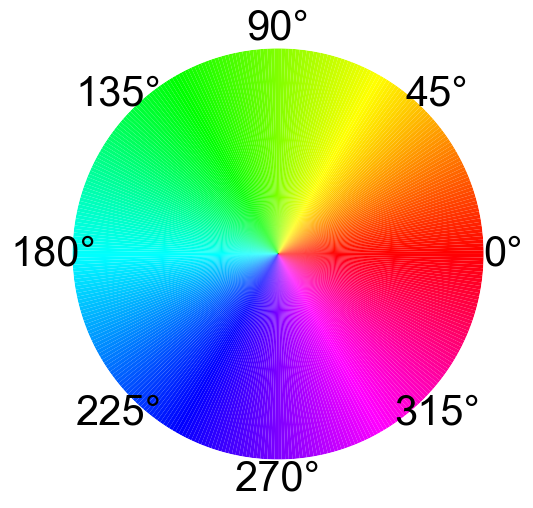

In [ ]:
"""Make hdir color wheel"""
# Create a figure
fig, ax = plt.subplots(figsize=(panel_size, panel_size), subplot_kw=dict(polar=True))

# Number of segments in the wheel (increased for smoother appearance)
N = 360  # More segments = smoother appearance

# Create color segments
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
width = np.ones(N) * 2*np.pi/N * 1.01  # Add 1% overlap to eliminate gaps
colors = [hsv_to_rgb([t/(2*np.pi), 1, 1]) for t in theta]

# Create the color wheel using pie chart
ax.bar(theta, np.ones(N), width=width, bottom=0.0, color=colors, 
       alpha=1.0, edgecolor='none', align='edge')

# Set the labels
ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels(['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°'])

# Remove y-ticks and radial lines
ax.set_yticks([])
ax.grid(False)

# Make the plot cleaner
ax.spines['polar'].set_visible(False)

# Set the limits to create a "donut" shape
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# Initialize the Figure_Saver
figure_saver = Figure_Saver(dir_save=save_path, format_save=["png"], overwrite = True)
figure_saver.save(fig, name_file='hdir_colorwheel')

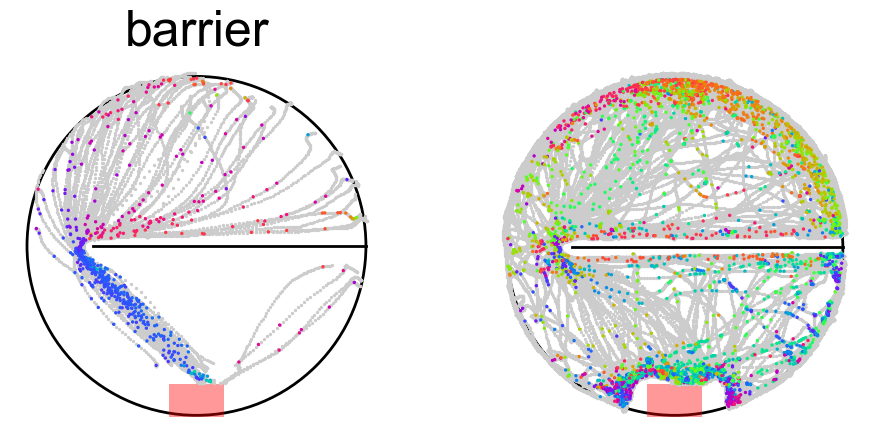

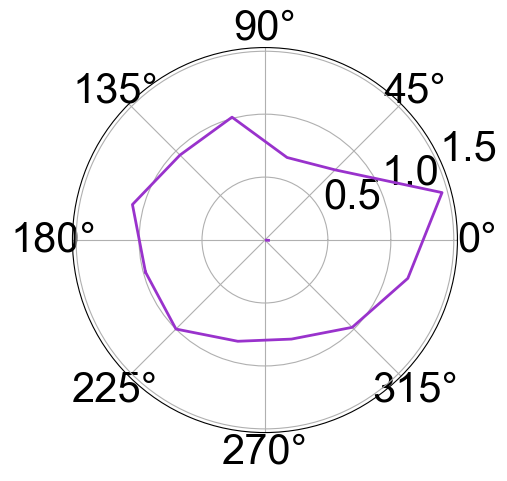

In [262]:
# """Plot spatial firing for a single neuron, but color the spikes by hdir,
# also make a polar plot for this neuron"""

selected = 51 # 190, 126, 51, 8 # the index of good neuron
clu = unit_ids[selected] # the KS cluster name

spikes = df.filter((df['spike_clusters'] == clu))

# for idx, condition in enumerate(conditions):
idx = 1
condition = 'barrier_pre_flip'
    
fig = plt.figure(figsize=(panel_size*2, panel_size))
gs = gridspec.GridSpec(1, 2, width_ratios=[5, 5])

# make the plot for homings
ax = fig.add_subplot(gs[0])
add_arena(ax, c_names[idx])

# plot the homing trajectories
filtered_df = filter_video_dataframe(dataframe=video_df, condition=condition, behavior = 'homing')
ax.scatter(filtered_df['mouse_x_position'], filtered_df['mouse_y_position'], color = [.8, .8, .8], s = dot_size)
# ax.scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = 1)

# plot the spikes
filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'homing')
hdir = np.digitize(np.rad2deg(filtered_df['hdir']), np.arange(-180, 180))
cc = hsv_hdir_colormap(hdir)
ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
            filtered_df['mouse_y_position'].to_numpy(), s = dot_size, c = cc)
ax.set_axis_off()
ax.invert_yaxis()
ax.set_aspect('equal')
ax.set_title(c_names[idx])

# make the plot for explore
ax = fig.add_subplot(gs[1])
add_arena(ax, c_names[idx])

# plot the homing trajectories
filtered_df = filter_video_dataframe(dataframe=video_df, condition=condition, behavior = 'exploring')
ax.scatter(filtered_df['mouse_x_position'], filtered_df['mouse_y_position'], color = [.8, .8, .8], s = dot_size)
# ax.scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = 1)

# plot the spikes
filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'exploring')
hdir = np.digitize(np.rad2deg(filtered_df['hdir']), np.arange(-180, 180))
cc = hsv_hdir_colormap(hdir)
ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
            filtered_df['mouse_y_position'].to_numpy(), s = dot_size, c = cc)
ax.set_axis_off()
ax.invert_yaxis()
ax.set_aspect('equal')

plt.tight_layout()

# Initialize the Figure_Saver
figure_saver = Figure_Saver(dir_save=save_path, format_save=["png"], overwrite = True)
figure_saver.save(fig, name_file=session_name + '_SpatialFiringHdir_Neuron' + str(selected) + '_Cluster' + str(clu) + '_' + c_names[idx])

"""Polar plot"""
fig = plt.figure(figsize=(panel_size, panel_size))
ax = plt.subplot(1, 1, 1, projection="polar")
color = 'darkorchid'

# Filter spike data
spike_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior='exploring')
spike_counts = spike_df['spike_count'].to_numpy()
spike_hdirs = spike_df['hdir'].to_numpy()

# Get all frames in this condition to calculate proper occupancy 
occupancy_df = filter_video_dataframe(dataframe=video_df, condition=condition, behavior='exploring')
all_hdirs = occupancy_df['hdir'].to_numpy()

# Create 12 bins (each 30 degrees)
n_bins = 12
bin_edges = np.linspace(-np.pi, np.pi, n_bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Get occupancy (time) in each head direction bin
occupancy_hist, _ = np.histogram(all_hdirs, bins=bin_edges)

# Get spike counts in each head direction bin
spike_hist, _ = np.histogram(spike_hdirs, bins=bin_edges, weights=spike_counts)

# Calculate firing rate (spikes divided by time in each bin)
epsilon = 1e-10  # Small value to prevent division by zero
firing_rate = spike_hist / (occupancy_hist + epsilon)

# Plot polar histogram
# Filter spike data
spike_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior='exploring')
spike_counts = spike_df['spike_count'].to_numpy()
spike_hdirs = spike_df['hdir'].to_numpy()

# Get all frames in this condition to calculate proper occupancy 
occupancy_df = filter_video_dataframe(dataframe=video_df, condition=condition, behavior='exploring')
all_hdirs = occupancy_df['hdir'].to_numpy()

# Create 12 bins (each 30 degrees)
n_bins = 12
bin_edges = np.linspace(-np.pi, np.pi, n_bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Get occupancy (time) in each head direction bin
occupancy_hist, _ = np.histogram(all_hdirs, bins=bin_edges)

# Get spike counts in each head direction bin
spike_hist, _ = np.histogram(spike_hdirs, bins=bin_edges, weights=spike_counts)

# Calculate firing rate (spikes divided by time in each bin)
epsilon = 1e-10  # Small value to prevent division by zero
firing_rate = (spike_hist / (occupancy_hist + epsilon))*40

# rayleigh
x = np.sum(np.cos(bin_centers) * (firing_rate)) / np.sum(firing_rate)
y = np.sum(np.sin(bin_centers) * (firing_rate)) / np.sum(firing_rate)
theta = np.arctan2(y, x)
r = np.sqrt(x**2 + y**2)

# Plot polar histogram
angles = np.append(bin_centers, bin_centers[0])
values = np.append(firing_rate, firing_rate[0])
ax.plot(angles, values, color=color, linewidth=2)
ax.vlines(theta, 0, r*np.amax(firing_rate), color=color, linewidth=2)

figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite = True)
figure_saver.save(fig, name_file=session_name + '_PolarPlotHdir_Neuron' + str(selected) + '_Cluster' + str(clu) + '_' + c_names[idx])


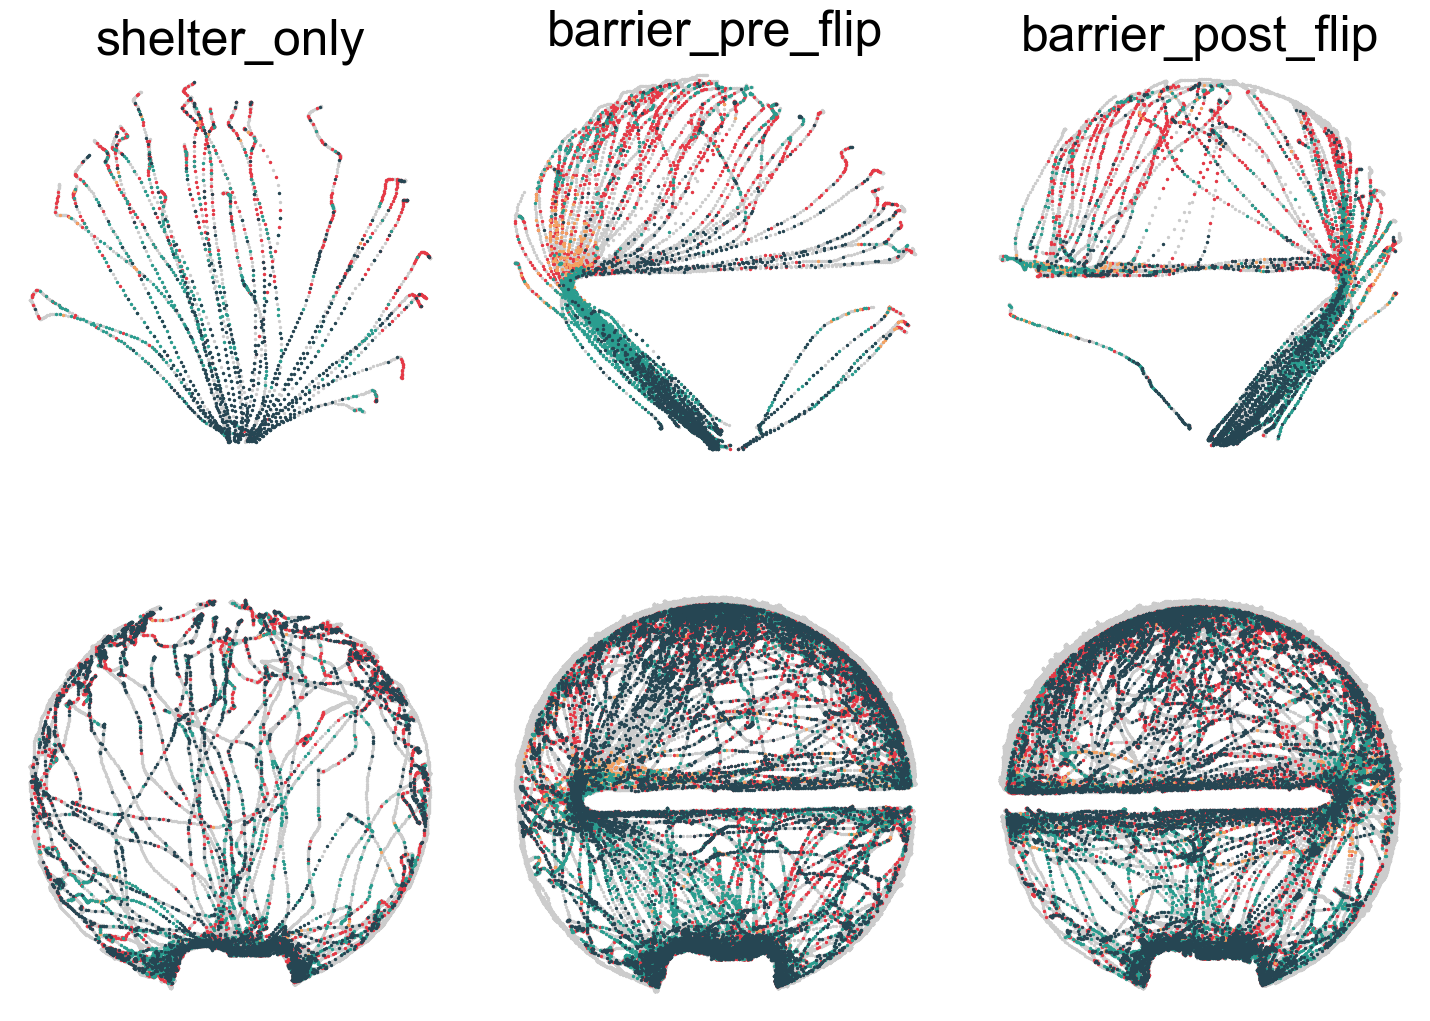

In [ ]:
"""Plot the spatial firing for x neurons that make up a sequence"""

selected = [119,139,224,226,102,272] # the index of good neuron
selected = [119,224,226,102] # the index of good neuron
selected = [17,215,126,229]
fig, axs = plt.subplots(2, 3, figsize=(panel_size*3, 2+(panel_size*2)))
colors = ["#E63946", "#F4A261", "#2A9D8F", "#264653"]  # Red, Orange, Teal, Dark Blue
# colors = [plt.get_cmap("tab10")(i) for i in range(4)]

for idx, condition in enumerate(conditions):
    # plot the homing trajectories
    axs[0,idx].scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = dot_size)
    axs[0,idx].set_axis_off()
    axs[0,idx].invert_yaxis()
    axs[0,idx].set_aspect('equal')
    axs[0,idx].set_title(condition)

    # plot the exploration behavior
    axs[1,idx].scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = dot_size)
    axs[1,idx].set_axis_off()
    axs[1,idx].invert_yaxis()
    axs[1,idx].set_aspect('equal')

    for n, s in enumerate(selected):
        clu = unit_ids[s] # the KS cluster name
        spikes = df.filter((df['spike_clusters'] == clu))
        # plot the homing spikes
        filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'homing')
        axs[0,idx].scatter(filtered_df['mouse_x_position'].to_numpy(),
                    filtered_df['mouse_y_position'].to_numpy(), s = dot_size, color = colors[n])

        # plot the exploration spikes
        filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = 'exploring')
        axs[1,idx].scatter(filtered_df['mouse_x_position'].to_numpy(),
                    filtered_df['mouse_y_position'].to_numpy(), s = dot_size, color = colors[n])

plt.tight_layout()

# nickname = exp.nick_name + '_' + exp.experiment_date
# exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'spatial firing'
# path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/" + nickname + "/" + exp_nickname)
# fig.savefig(path + "\\" + f'Neuron_{selected}_homingVsExplore_spatial_firing.png')
# plt.clf()
# plt.close("all")


RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_SpatialFiring_Remap_Neuron129_Cluster270.png already exists.


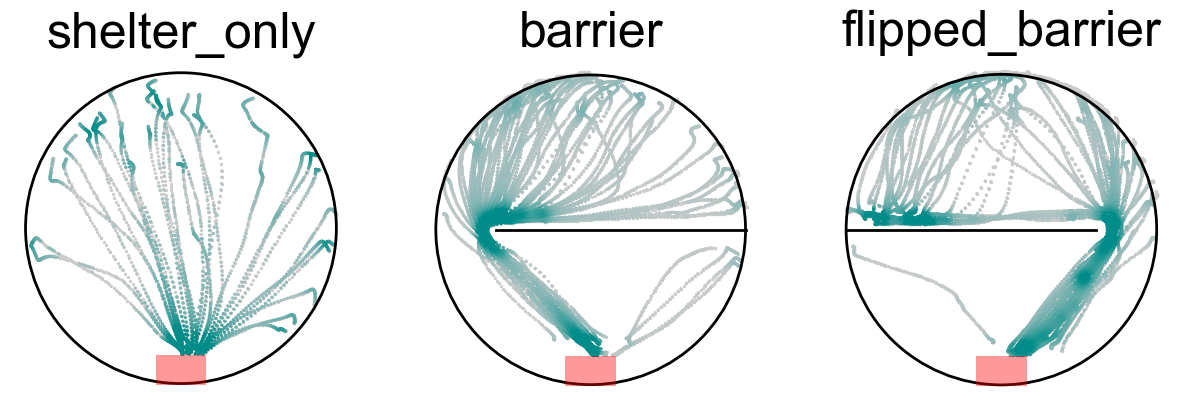

In [ ]:
"""Plot the spatial firing for x neurons that do or don't remap,
but use smoothed firing rates"""

remappers = [229, 102, 124] # [229,106/129,13]
remappers = [229, 106, 13]
remappers = [129]

colors = [
    "#264653",  # Dark Blue - doesn't remap
    '#008DB9', # Light Blue - remaps to goal
    '#B100B9' # Pink - remaps to 2nd leg
]
colors = ['#008D89']
grey = [0.8, 0.8, 0.8]
custom_cmaps = []

# Create each custom colormap
for i, color_hex in enumerate(colors):
    # Convert hex to RGB
    color_rgb = mcolors.hex2color(color_hex)
    
    # Create the colormap
    cmap = mcolors.LinearSegmentedColormap.from_list(f'grey_to_{i}', [grey, color_rgb])
    custom_cmaps.append(cmap)

for n, selected in enumerate(remappers):
    fig, axs = plt.subplots(2, 3, figsize=(panel_size*3, (panel_size*2)))
    clu = unit_ids[selected] # the KS cluster name
    spikes = df.filter((df['spike_clusters'] == clu))

    for idx, condition in enumerate(conditions):

        for he, behavior in enumerate(['homing', 'exploring']):
            # make the plot for homings
            ax = axs[he,idx]
            if he == 0:
                # plot the homing trajectories
                ax.scatter(X[h_cond == idx], Y[h_cond == idx], color = [.8, .8, .8], s = dot_size)
                ax.set_title(c_names[idx])
            elif he == 1:
                # plot the exploration behavior
                ax.scatter(X_exp[exp_cond == idx], Y_exp[exp_cond == idx], color = [.8, .8, .8], s = dot_size)

            # plot the spikes
            filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = behavior)
            density = compute_spatial_density(filtered_df['mouse_x_position'].to_numpy(),
                                            filtered_df['mouse_y_position'].to_numpy(), bandwidth=80)
            ax.scatter(filtered_df['mouse_x_position'].to_numpy(),
                        filtered_df['mouse_y_position'].to_numpy(), s = dot_size, 
                        c = density, cmap = custom_cmaps[n],
                        norm=plt.Normalize(vmin=0, vmax=np.max(density)*0.4))
            
            add_arena(ax, c_names[idx])
            ax.set_axis_off()
            ax.invert_yaxis()
            ax.set_aspect('equal')

    figure_saver = Figure_Saver(dir_save=save_path, format_save=["png"], overwrite = True)
    figure_saver.save(fig, name_file=session_name + '_SpatialFiring_Remap_Neuron' + str(selected) + '_Cluster' + str(clu))

RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_PositionHeatmap_Neuron14_Cluster34_barrier.pdf already exists.
RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_PositionHeatmap_Neuron93_Cluster208_barrier.pdf already exists.
RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_PositionHeatmap_Neuron5_Cluster14_barrier.pdf already exists.


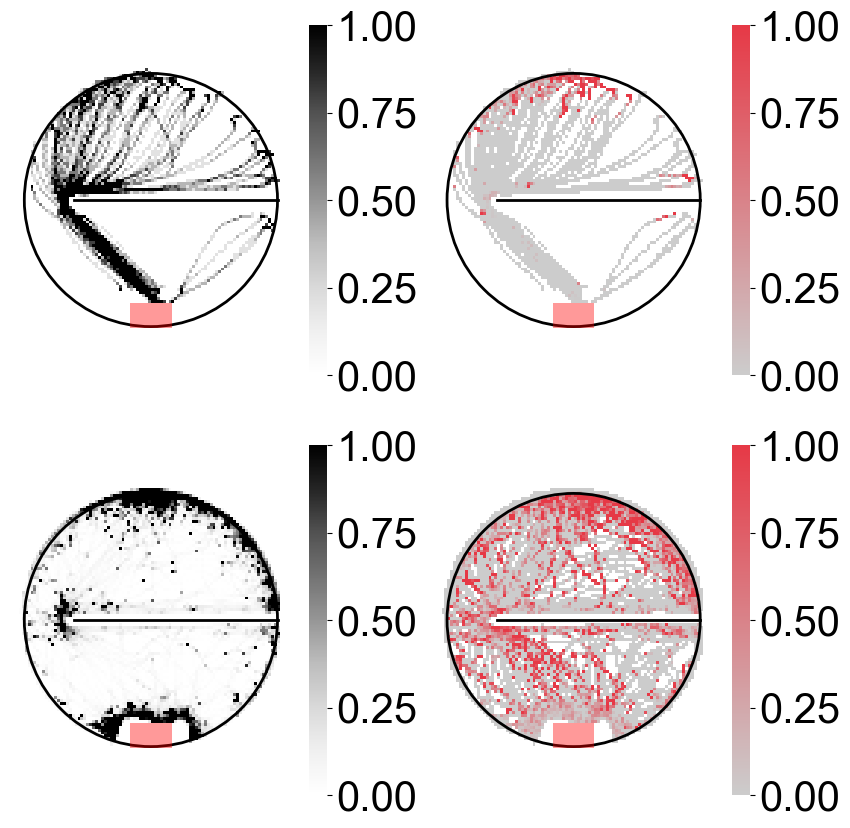

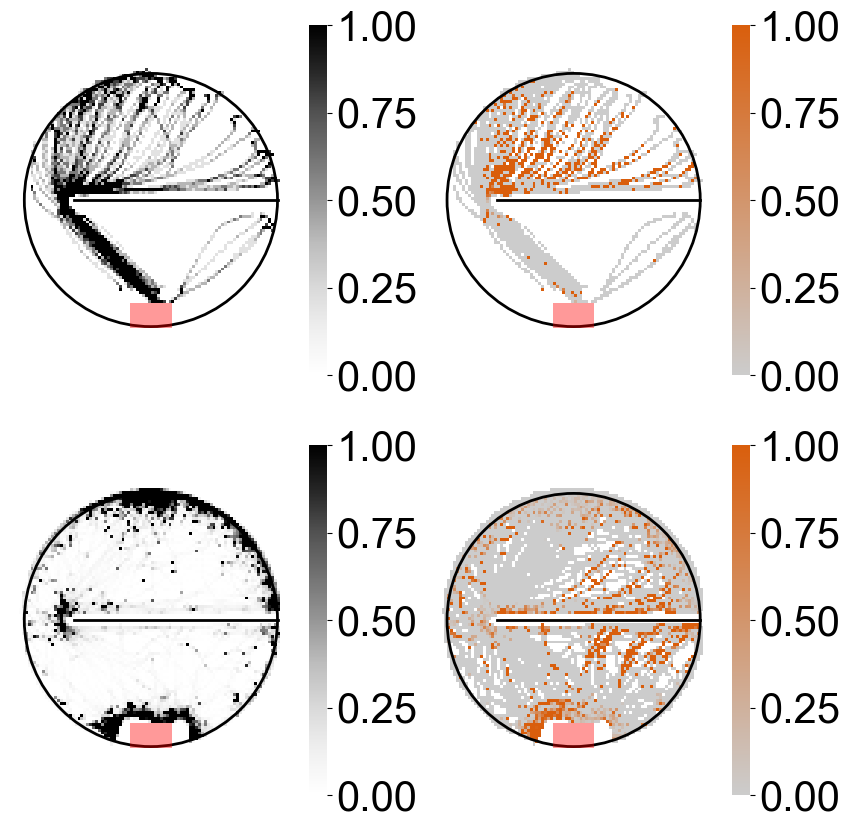

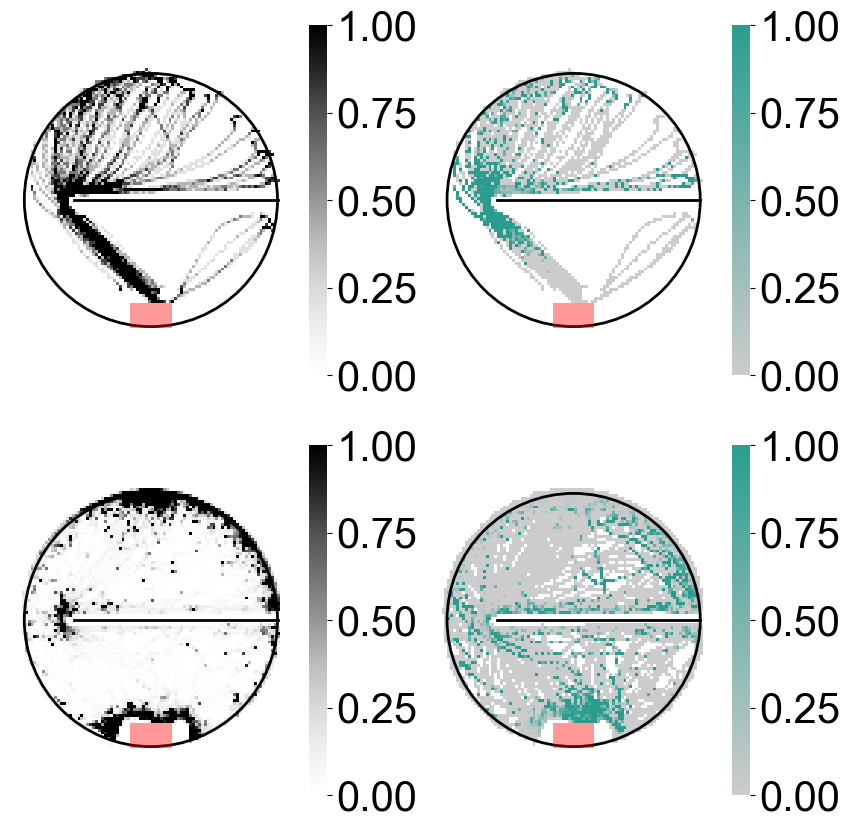

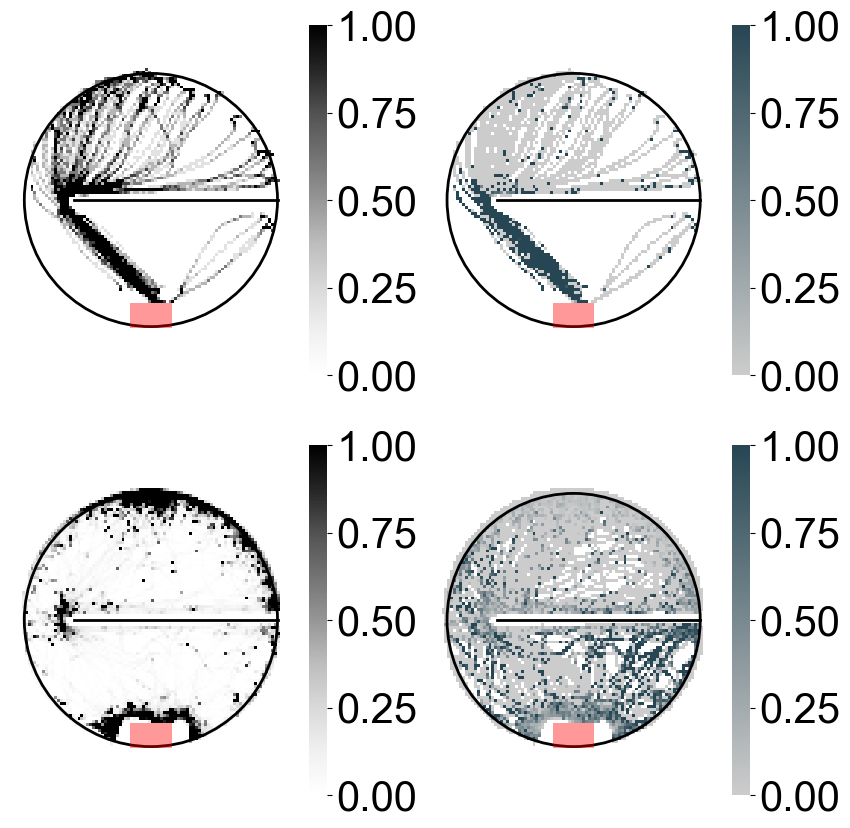

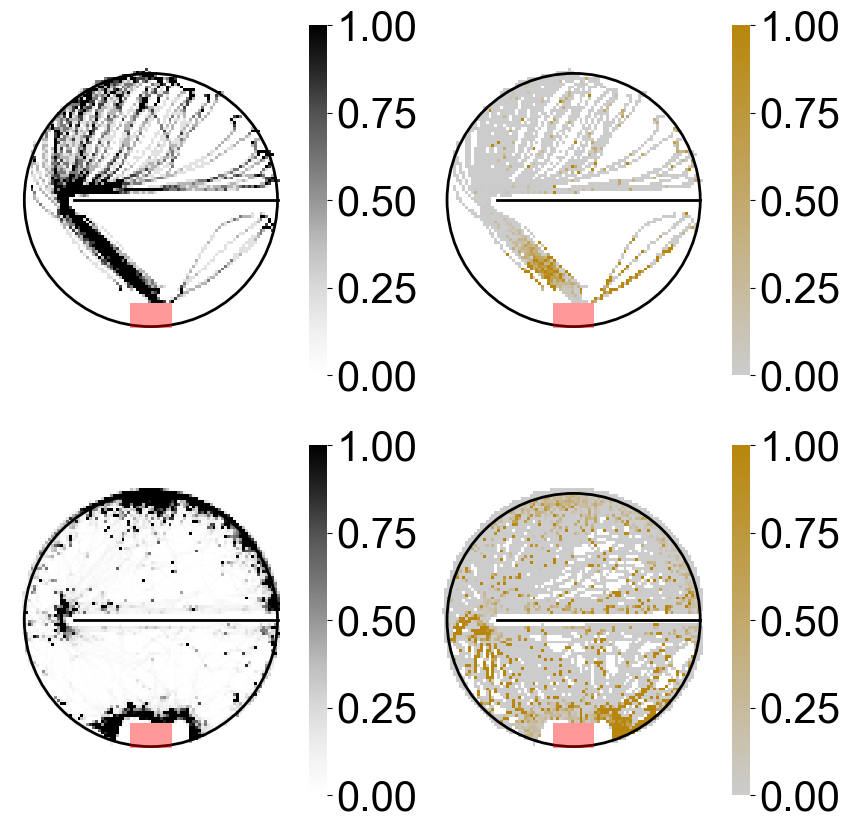

In [271]:
"""Make position normalized heatmpa of activity for a single neuron"""
nbins = 96
selected = [119,14,93,5,214]#red: 270, 119 orange: 14, 17, 122 teal: 93, dark blue: 5, gold/amber: 272, 239, 214
idx = 1
condition = conditions[idx]
behavior = ['homing', 'exploring']

colors = ["#E63946", "#F4A261", "#2A9D8F", "#264653", "#FFB74D"]
colors = ["#E63946", "#D95E0C", "#2A9D8F", "#264653", "#B8860B"]
grey = [0.8, 0.8, 0.8]
custom_cmaps = []

# Create each custom colormap
for i, color_hex in enumerate(colors):
    # Convert hex to RGB
    color_rgb = mcolors.hex2color(color_hex)
    
    # Create the colormap
    cmap = mcolors.LinearSegmentedColormap.from_list(f'grey_to_{i}', [grey, color_rgb])
    custom_cmaps.append(cmap)

# make heatmap plot for each neuron
for n, s in enumerate(selected):

    fig, axs = plt.subplots(len(behavior), 2, figsize=(panel_size*2, panel_size*len(behavior)))
    
    clu = unit_ids[s] # the KS cluster name
    spikes = df.filter((df['spike_clusters'] == clu))
    
    for b_idx, be in enumerate(behavior):
        # make a heatmap of spatial occupancy in exploration
        ax = axs[b_idx, 0]
        ax.set_axis_off()
        ax.set_aspect('equal')

        if be == 'homing':
            occupancy_heatmap, xedges, yedges = np.histogram2d(
                X[h_cond == idx], Y[h_cond == idx], bins=(nbins, nbins),
                range=[[0, 1024], [0, 1024]])
        elif be == 'exploring':
            occupancy_heatmap, xedges, yedges = np.histogram2d(
                X_exp[exp_cond == idx], Y_exp[exp_cond == idx], bins=(nbins, nbins),
                range=[[0, 1024], [0, 1024]])  # [int, int] - number of bins in x and y axis, abitrarily set

        # Plotting logic for the heatmap, transpose to get the right orientation and set zero to white
        ax = sns.heatmap(
            occupancy_heatmap.T / np.percentile(occupancy_heatmap,95),
            cmap="Greys",
            robust=True,
            ax=ax,
            mask=(occupancy_heatmap.T == 0),
            norm=plt.Normalize(vmin=0, vmax=1),
            cbar = True
        )
        add_arena(ax, c_names[idx], scale = nbins/1024)

        # make a heatmap of neural activity normalized by spatial occupancy
        ax = axs[b_idx, 1]
        ax.set_axis_off()
        ax.set_aspect('equal')

        filtered_df = filter_video_dataframe(dataframe=spikes, condition=condition, behavior = be)
        spike_heatmap, _, _ = np.histogram2d(
            filtered_df['mouse_x_position'].to_numpy(), 
            filtered_df['mouse_y_position'].to_numpy(), bins=(nbins, nbins),
            range=[[0, 1024], [0, 1024]],
            weights = filtered_df['spike_count'].to_numpy(),
        )

        # Add small value to prevent division by zero
        epsilon = 1e-10
        normalized_heatmap = np.divide(
            spike_heatmap, 
            occupancy_heatmap + epsilon,
            out=np.zeros_like(spike_heatmap),
        )

        # Plot the normalized heatmap
        normalizer = np.percentile(normalized_heatmap,95)
        if normalizer == 0:
            normalizer = 1
        sns_heatmap = sns.heatmap(
            normalized_heatmap.T/ normalizer,
            cmap=custom_cmaps[n],
            robust=True,
            ax=ax,
            mask=(occupancy_heatmap.T == 0),
            norm=plt.Normalize(vmin=0, vmax=1),
            cbar = True)
        
        add_arena(ax, c_names[idx], scale = nbins/1024)

    figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite = True)
    figure_saver.save(fig, name_file=session_name + '_PositionHeatmap_Neuron' + str(s) + '_Cluster' + str(clu) + '_' + c_names[idx])

RH Warning: Overwriting file. File: \\ceph-gw02.hpc.swc.ucl.ac.uk\branco\Jasmine_Laurence\summary_plots\Cosyne\JAL6_flip4_21mar_Reliability_Neuron95.pdf already exists.


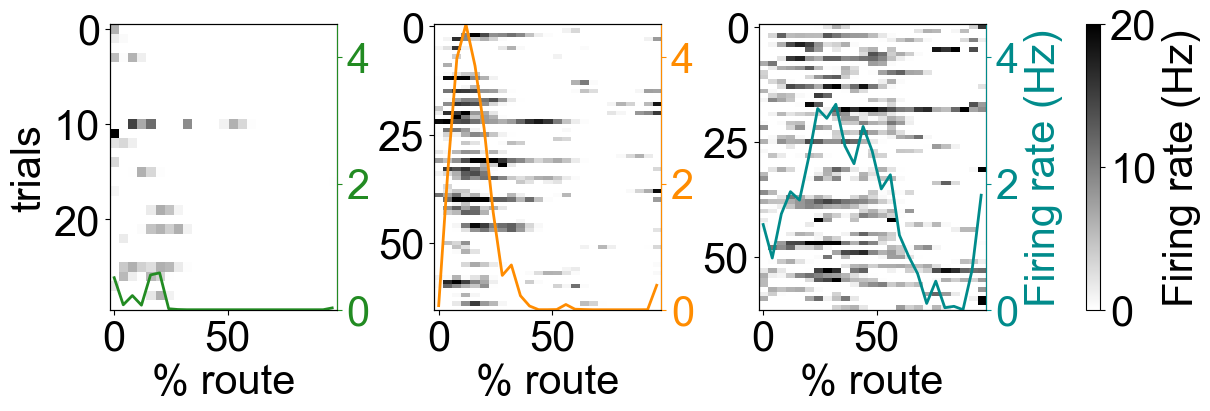

In [142]:
"""Make a plot of reliability of a given neuron"""

# JAL6_21march: 95, 244,239
# JAL5_8sep: 89
neur = 95

# 1. load in explore tuning curve
exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')

mat_full_cond = data['mat_full_cond']
fr_full = data['fr_full']
fr_full = data['fr_full']

# compute min/max for this neuron across all conditions
vmin, vmax = np.nanmin(mat_full_cond, axis=(0, 2, 3)), np.nanmax(mat_full_cond, axis=(0, 2, 3))  # Ignore NaNs
vmin[neur], vmax[neur] = 0, 20

# compute min/max for the average also
ymin, ymax = [np.nanmin(fr_full, axis=(0, 2)), np.nanmax(fr_full, axis=(0, 2))]

fig, axs = plt.subplots(1,3, figsize = (12,4), constrained_layout=True)

ylim = [ymin[neur], ymax[neur]]
if ylim == [0,0]: ylim = [0,1]

for c in range(3):
    nan_rows = np.all(np.isnan(mat_full_cond[c,neur,:,:]), axis=1)
    im = axs[c].imshow(mat_full_cond[c,neur,~nan_rows,:], cmap="gray_r", vmin = vmin[neur], vmax = vmax[neur], aspect="auto", interpolation = "none")
    axs[c]. set_xlabel(r'% route')
    if c == 0:
        axs[c].set_ylabel('trials')
    axs[c].set_xticks([0, 12.5, 25])
    axs[c].set_xticklabels(['0', '50', '100'])

    ax2 = axs[c].twinx()
    ax2.plot(fr_full[c,neur,:], linewidth = 2, color = cond_colors[c])
    ax2.spines["right"].set_color(cond_colors[c])
    ax2.tick_params(axis="y", colors=cond_colors[c])  # Change tick color
    ax2.yaxis.label.set_color(cond_colors[c])  # Change axis label color
    ax2.set_ylim(ylim)
    
    if c == 2:
        ax2.set_ylabel('Firing rate (Hz)')
        cbar = fig.colorbar(im, ax=axs[c], location="right", pad=0.1)
        cbar.set_label('Firing rate (Hz)')

# Initialize the Figure_Saver
figure_saver = Figure_Saver(dir_save=save_path, format_save=["pdf"], overwrite = True)
figure_saver.save(fig, name_file=session_name + '_Reliability_Neuron' + str(neur))